# Speculative Decoding Benchmark Charts

Visualizations comparing baseline vs speculative decoding on DGX Spark.

In [2]:
%pip install pandas matplotlib numpy

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 57.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 70.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 72.5 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 74.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 77.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load all benchmark CSVs (using the confirmed run-2 data for eagle)
baseline_eagle = pd.read_csv('baseline-eagle-2.csv')
eagle3 = pd.read_csv('eagle3-2.csv')
baseline_draft = pd.read_csv('baseline-draft.csv')
draft_target = pd.read_csv('draft-target.csv')

all_data = pd.concat([baseline_eagle, eagle3, baseline_draft, draft_target], ignore_index=True)

PROMPT_LABELS = {
    0: 'P1: Relativity\nexplanation',
    1: 'P2: Hash table\nimplementation',
    2: 'P3: Train math\nproblem'
}
all_data['prompt_label'] = all_data['prompt_idx'].map(PROMPT_LABELS)

MODE_LABELS = {
    'baseline-eagle': 'Baseline\n(GPT-OSS-120B)',
    'eagle3': 'EAGLE-3\n(GPT-OSS-120B)',
    'baseline-draft': 'Baseline\n(Llama-70B)',
    'draft-target': 'Draft-Target\n(Llama-70B + 8B)'
}
all_data['mode_label'] = all_data['mode'].map(MODE_LABELS)

# Split into the two model groups
eagle_data = all_data[all_data['mode'].isin(['baseline-eagle', 'eagle3'])]
draft_data = all_data[all_data['mode'].isin(['baseline-draft', 'draft-target'])]

all_data.head()

,mode,prompt_idx,run,tokens,wall_time_s,tokens_per_sec,ttft_s,avg_decoded_per_iter,prompt_label,mode_label
0,baseline-eagle,0,1,200,6.331063,31.59,6.330978,1.0,P1: Relativity\nexplanation,Baseline\n(GPT-OSS-120B)
1,baseline-eagle,0,2,200,6.333517,31.58,6.333343,1.0,P1: Relativity\nexplanation,Baseline\n(GPT-OSS-120B)
2,baseline-eagle,0,3,200,6.325749,31.62,6.325644,1.0,P1: Relativity\nexplanation,Baseline\n(GPT-OSS-120B)
3,baseline-eagle,1,1,200,6.326103,31.62,6.326031,1.0,P2: Hash table\nimplementation,Baseline\n(GPT-OSS-120B)
4,baseline-eagle,1,2,200,6.355675,31.47,6.355592,1.0,P2: Hash table\nimplementation,Baseline\n(GPT-OSS-120B)


## Overall Comparison: Tokens/sec and TTFT

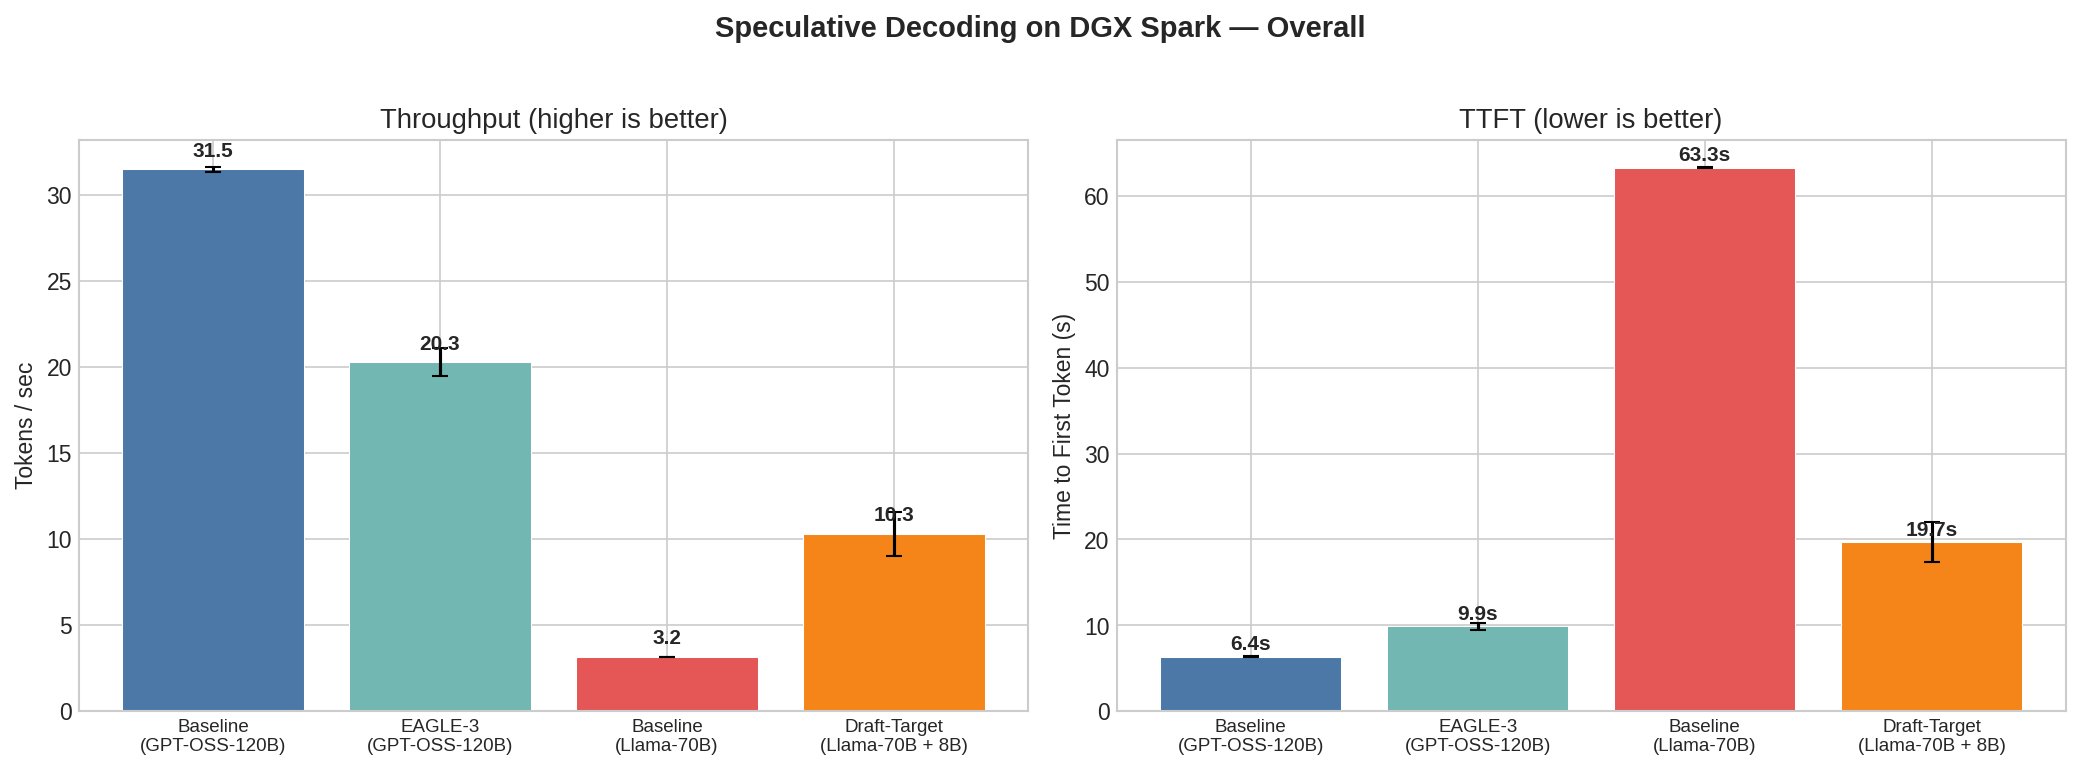

In [4]:
# Aggregate stats per mode
summary = all_data.groupby(['mode', 'mode_label']).agg(
    tps_mean=('tokens_per_sec', 'mean'),
    tps_std=('tokens_per_sec', 'std'),
    ttft_mean=('ttft_s', 'mean'),
    ttft_std=('ttft_s', 'std'),
    avg_per_iter=('avg_decoded_per_iter', 'mean')
).reset_index()

# Order: baseline-eagle, eagle3, baseline-draft, draft-target
mode_order = ['baseline-eagle', 'eagle3', 'baseline-draft', 'draft-target']
summary['sort'] = summary['mode'].map({m: i for i, m in enumerate(mode_order)})
summary = summary.sort_values('sort')

colors = ['#4C78A8', '#72B7B2', '#E45756', '#F58518']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -- Tokens/sec bar chart --
bars1 = ax1.bar(range(len(summary)), summary['tps_mean'], 
               yerr=summary['tps_std'], capsize=4,
               color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xticks(range(len(summary)))
ax1.set_xticklabels(summary['mode_label'], fontsize=9)
ax1.set_ylabel('Tokens / sec')
ax1.set_title('Throughput (higher is better)')
for bar, val in zip(bars1, summary['tps_mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# -- TTFT bar chart --
bars2 = ax2.bar(range(len(summary)), summary['ttft_mean'],
               yerr=summary['ttft_std'], capsize=4,
               color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(len(summary)))
ax2.set_xticklabels(summary['mode_label'], fontsize=9)
ax2.set_ylabel('Time to First Token (s)')
ax2.set_title('TTFT (lower is better)')
for bar, val in zip(bars2, summary['ttft_mean']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('Speculative Decoding on DGX Spark — Overall', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart-overall.png', bbox_inches='tight', dpi=150)
plt.show()

## Per-Prompt Breakdown: GPT-OSS-120B (EAGLE-3 vs Baseline)

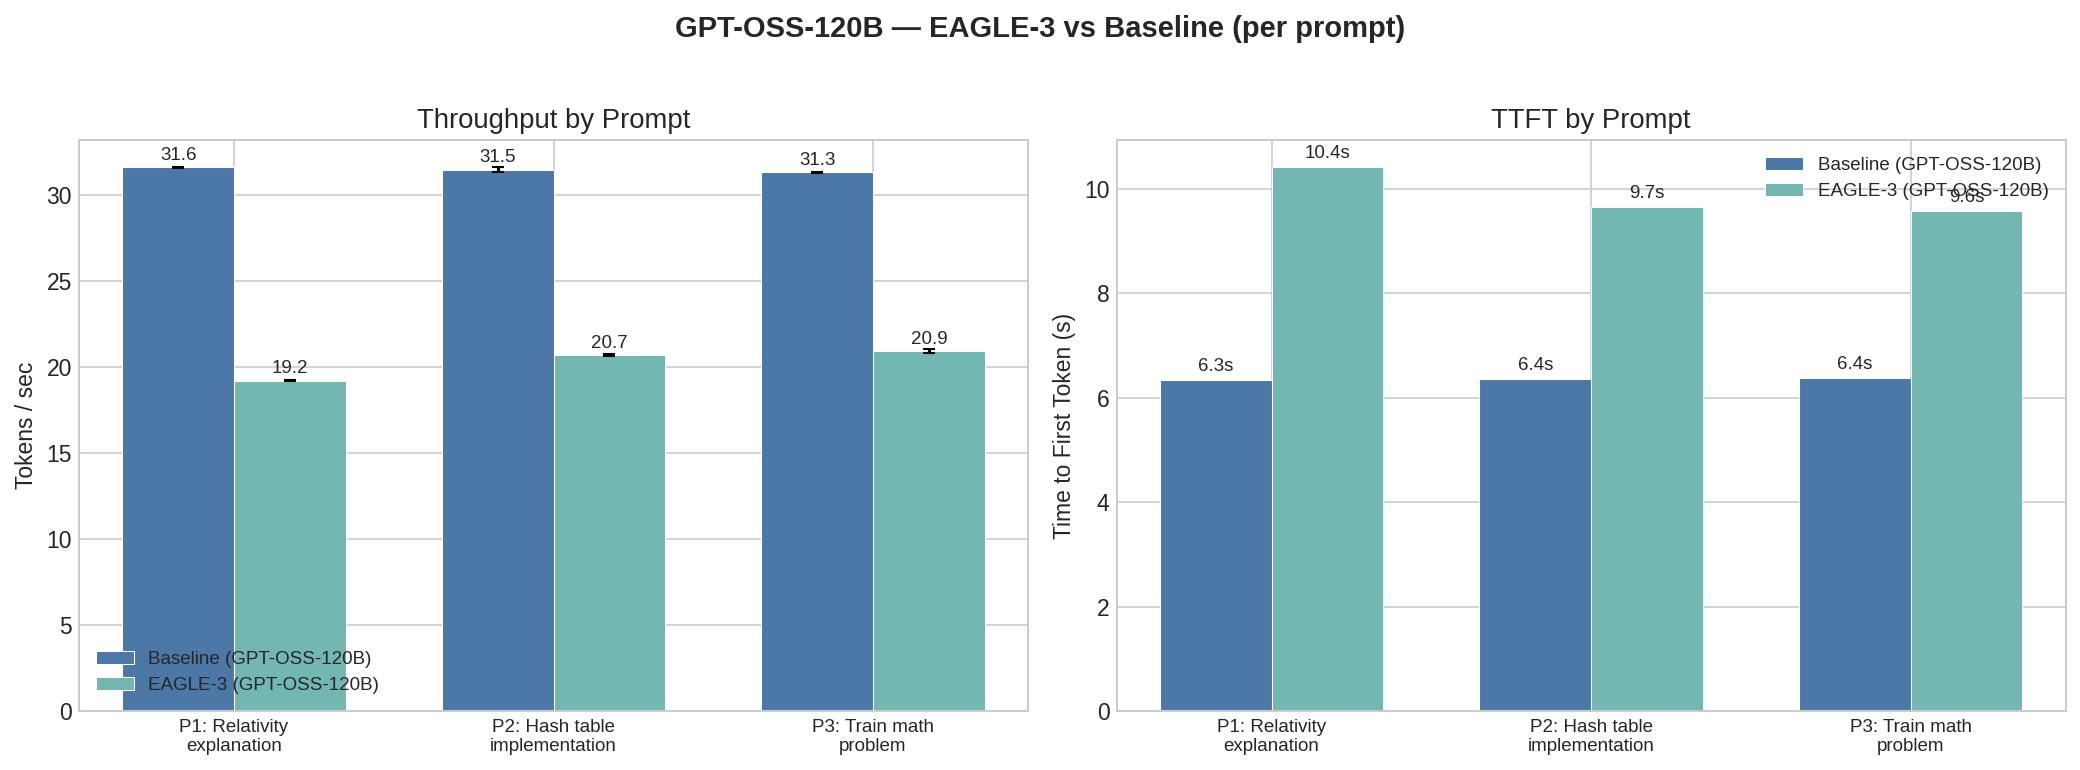

In [5]:
def per_prompt_chart(data, title, filename, colors_pair):
    """Grouped bar chart: per-prompt tok/s for two modes."""
    modes = data['mode'].unique()
    prompts = sorted(data['prompt_idx'].unique())
    
    stats = data.groupby(['mode', 'prompt_idx']).agg(
        tps_mean=('tokens_per_sec', 'mean'),
        tps_std=('tokens_per_sec', 'std'),
        ttft_mean=('ttft_s', 'mean'),
        avg_per_iter=('avg_decoded_per_iter', 'mean')
    ).reset_index()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    x = np.arange(len(prompts))
    width = 0.35
    
    for i, mode in enumerate(modes):
        mode_stats = stats[stats['mode'] == mode].sort_values('prompt_idx')
        label = MODE_LABELS[mode]
        offset = -width/2 + i * width
        
        # Tokens/sec
        bars = ax1.bar(x + offset, mode_stats['tps_mean'], width,
                       yerr=mode_stats['tps_std'], capsize=3,
                       label=label.replace('\n', ' '), color=colors_pair[i],
                       edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, mode_stats['tps_mean']):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=9)
        
        # TTFT
        bars = ax2.bar(x + offset, mode_stats['ttft_mean'], width,
                       label=label.replace('\n', ' '), color=colors_pair[i],
                       edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, mode_stats['ttft_mean']):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.1f}s', ha='center', va='bottom', fontsize=9)
    
    prompt_labels = [PROMPT_LABELS[p] for p in prompts]
    ax1.set_xticks(x)
    ax1.set_xticklabels(prompt_labels, fontsize=9)
    ax1.set_ylabel('Tokens / sec')
    ax1.set_title('Throughput by Prompt')
    ax1.legend(fontsize=9)
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(prompt_labels, fontsize=9)
    ax2.set_ylabel('Time to First Token (s)')
    ax2.set_title('TTFT by Prompt')
    ax2.legend(fontsize=9)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight', dpi=150)
    plt.show()

per_prompt_chart(
    eagle_data,
    'GPT-OSS-120B — EAGLE-3 vs Baseline (per prompt)',
    'chart-eagle3-per-prompt.png',
    ['#4C78A8', '#72B7B2']
)

## Per-Prompt Breakdown: Llama-3.3-70B (Draft-Target vs Baseline)

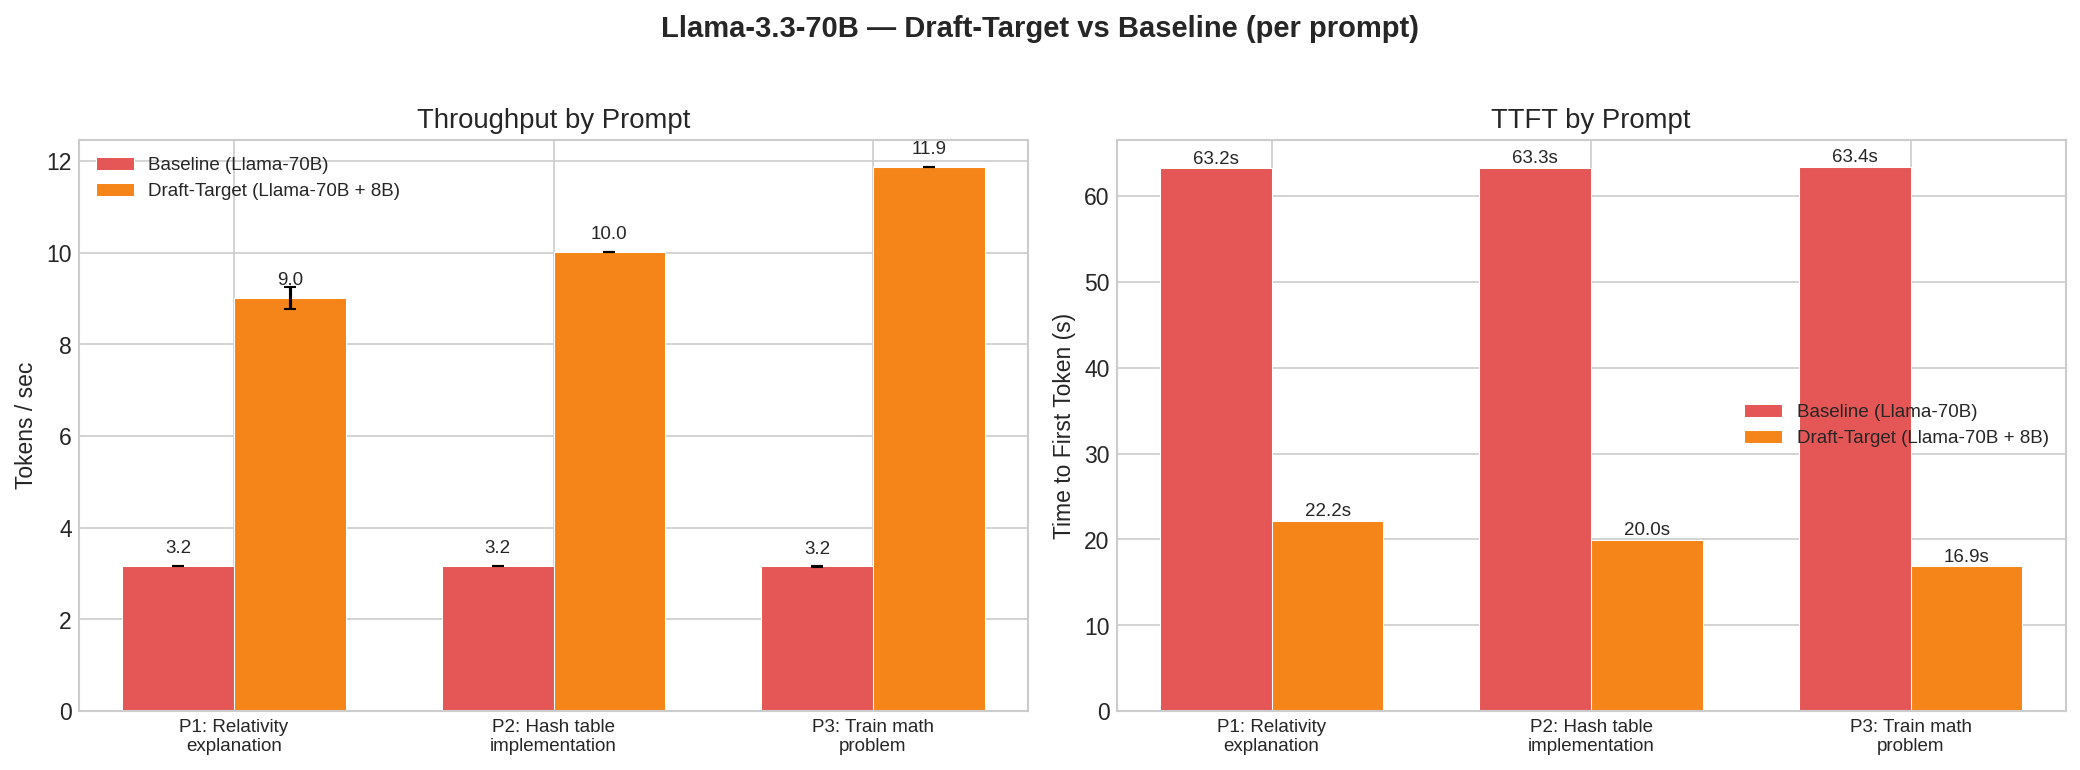

In [6]:
per_prompt_chart(
    draft_data,
    'Llama-3.3-70B — Draft-Target vs Baseline (per prompt)',
    'chart-draft-target-per-prompt.png',
    ['#E45756', '#F58518']
)

## Avg Decoded Tokens per Iteration (Speculation Acceptance)

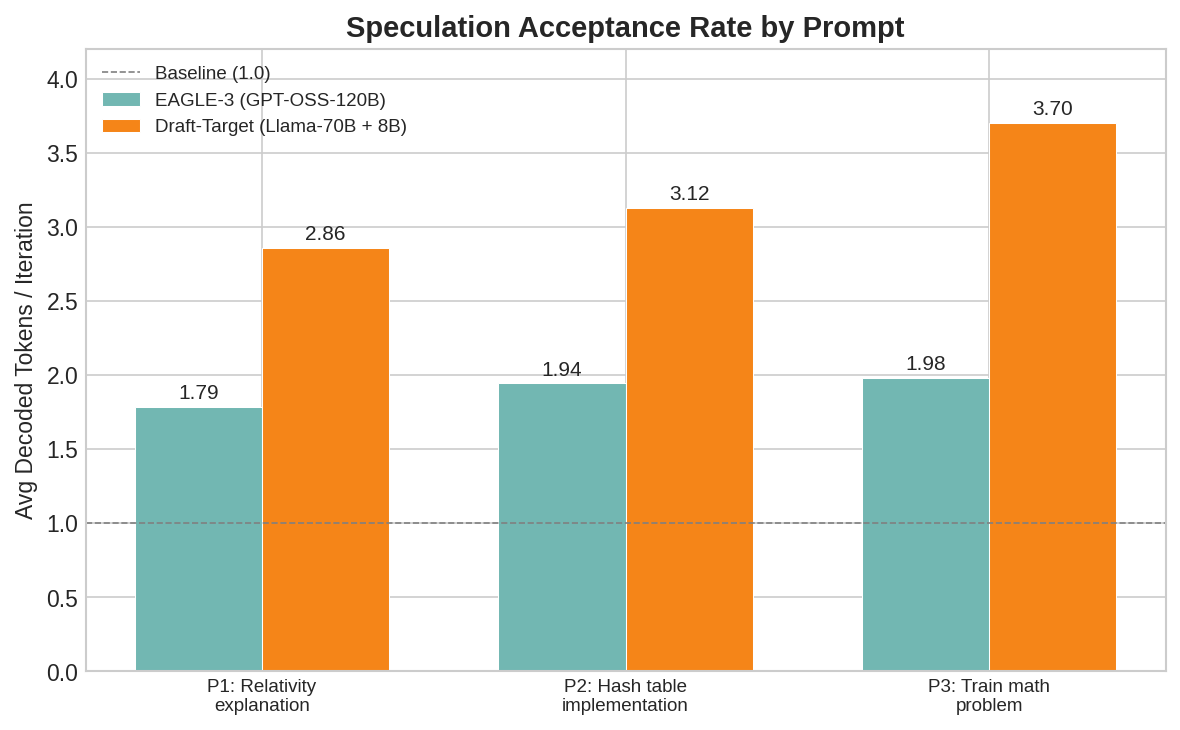

In [7]:
# Only speculative modes (baseline is always 1.0)
spec_data = all_data[all_data['mode'].isin(['eagle3', 'draft-target'])]
spec_stats = spec_data.groupby(['mode', 'prompt_idx']).agg(
    avg_per_iter=('avg_decoded_per_iter', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(PROMPT_LABELS))
width = 0.35
spec_colors = ['#72B7B2', '#F58518']

for i, mode in enumerate(['eagle3', 'draft-target']):
    mode_stats = spec_stats[spec_stats['mode'] == mode].sort_values('prompt_idx')
    offset = -width/2 + i * width
    bars = ax.bar(x + offset, mode_stats['avg_per_iter'], width,
                  label=MODE_LABELS[mode].replace('\n', ' '),
                  color=spec_colors[i], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, mode_stats['avg_per_iter']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, label='Baseline (1.0)')
ax.set_xticks(x)
ax.set_xticklabels([PROMPT_LABELS[p] for p in sorted(PROMPT_LABELS.keys())], fontsize=9)
ax.set_ylabel('Avg Decoded Tokens / Iteration')
ax.set_title('Speculation Acceptance Rate by Prompt', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 4.2)

plt.tight_layout()
plt.savefig('chart-acceptance-rate.png', bbox_inches='tight', dpi=150)
plt.show()

## Summary Table

In [9]:
%pip install jinja2


summary_display = summary[['mode_label', 'tps_mean', 'tps_std', 'ttft_mean', 'avg_per_iter']].copy()
summary_display.columns = ['Mode', 'Avg tok/s', 'Std tok/s', 'Avg TTFT (s)', 'Avg tokens/iter']
summary_display['Avg tok/s'] = summary_display['Avg tok/s'].map('{:.1f}'.format)
summary_display['Std tok/s'] = summary_display['Std tok/s'].map('{:.2f}'.format)
summary_display['Avg TTFT (s)'] = summary_display['Avg TTFT (s)'].map('{:.2f}'.format)
summary_display['Avg tokens/iter'] = summary_display['Avg tokens/iter'].map('{:.2f}'.format)
summary_display['Mode'] = summary_display['Mode'].str.replace('\n', ' ')
summary_display.style.hide(axis='index')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jinja2]
Note: you may need to restart the kernel to use updated packages.


Mode,Avg tok/s,Std tok/s,Avg TTFT (s),Avg tokens/iter
Baseline (GPT-OSS-120B),31.5,0.14,6.36,1.00
EAGLE-3 (GPT-OSS-120B),20.3,0.81,9.88,1.90
Baseline (Llama-70B),3.2,0.00,63.31,1.00
Draft-Target (Llama-70B + 8B),10.3,1.26,19.68,3.23
